### Dependencies

In [ ]:
import openai
import pandas as pd
import random

from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display
from typing import Literal

from pydantic import BaseModel
from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

Single Node Graph

In [153]:
class State(BaseModel):
    message: str
    answer: str = ""
    vibe: str


In [154]:
def append_vibes_to_query(state: State) -> dict:
    return{
        "answer": f"{state.message} {state.vibe}"
    }

In [155]:
workflow = StateGraph(State)
workflow.add_node("append_vibes_to_query", append_vibes_to_query)

workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibes_to_query", END)

graph = workflow.compile()

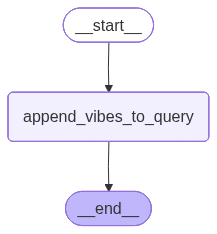

In [156]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [157]:
initial_state = {
    "message": "Give me some vibes!",
    "vibe": "I'm feeling like a badass today!"
}

In [158]:
result = graph.invoke(initial_state)

In [159]:
result

{'message': 'Give me some vibes!',
 'answer': "Give me some vibes! I'm feeling like a badass today!",
 'vibe': "I'm feeling like a badass today!"}

In [160]:
initial_state = {
    "message": "Give me some vibes!",
    "answer": "abc",
    "vibe": "I'm feeling like a badass today!"
}

In [161]:
result = graph.invoke(initial_state)

In [162]:
#answer key will overwrite 
result

{'message': 'Give me some vibes!',
 'answer': "Give me some vibes! I'm feeling like a badass today!",
 'vibe': "I'm feeling like a badass today!"}

### Conditional Graph

In [163]:
class State(BaseModel):
    message: str
    answer: str = ""

In [164]:
def append_vibes_to_query(state: State) -> dict:
    return{
        "answer": state.message
    }

In [165]:
# always return dictionary
def append_vibe_1(state: State) -> dict:
    vibe = "I'm feeling like a badass today!"

    return{
        "answer": f"{state.message} {vibe}"
    }

In [166]:
def append_vibe_2(state: State) -> dict:
    vibe = "I'm feeling like a boss today!"

    return{
        "answer": f"{state.message} {vibe}"
    }

In [167]:
def append_vibe_3(state: State) -> dict:
    vibe = "I'm feeling like a legend today!"

    return{
        "answer": f"{state.message} {vibe}"
    }

In [168]:
def router(state: State) -> Literal["badass", "boss", "legend"]:
    choices = ["badass", "boss", "legend"]
    return random.choice(choices)

In [169]:
workflow = StateGraph(State)
workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

workflow.add_conditional_edges(
    "append_vibes_to_query",
    router,
    {
        "badass": "append_vibe_1",
        "boss": "append_vibe_2",
        "legend": "append_vibe_3",
    }
)

workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)

graph = workflow.compile()

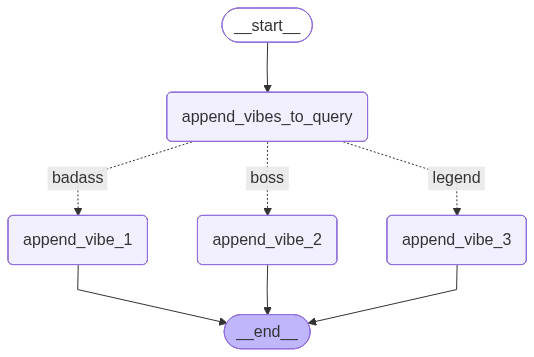

In [170]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [171]:
initial_state = {
    "message": "I am here to add some vibes:"
}

In [172]:
result = graph.invoke(initial_state)

In [173]:
result

{'message': 'I am here to add some vibes:',
 'answer': "I am here to add some vibes: I'm feeling like a legend today!"}

In [174]:
result = graph.invoke(initial_state)

In [175]:
result

{'message': 'I am here to add some vibes:',
 'answer': "I am here to add some vibes: I'm feeling like a legend today!"}

In [188]:
def router2(state: State) -> Literal["append_vibe_1", "append_vibe_2", "append_vibe_3"]:

    vibes = ["append_vibe_1", "append_vibe_2", "append_vibe_3"]

    vibe_path = random.choice(vibes)

    return vibe_path

In [189]:
workflow2 = StateGraph(State)

workflow2.add_node("append_vibe_1", append_vibe_1)
workflow2.add_node("append_vibe_2", append_vibe_2)
workflow2.add_node("append_vibe_3", append_vibe_3)

workflow2.add_conditional_edges(
    START,
    router2,
    {
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3"
    }
)

workflow2.add_edge("append_vibe_1", END)
workflow2.add_edge("append_vibe_2", END)
workflow2.add_edge("append_vibe_3", END)

graph2 = workflow2.compile()

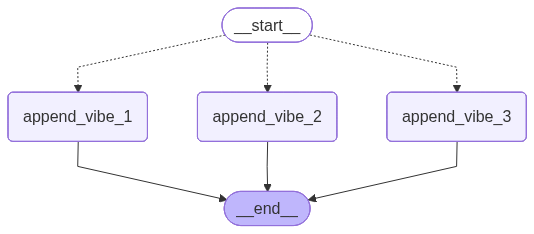

In [190]:
display(Image(graph2.get_graph().draw_mermaid_png()))

In [191]:
result = graph2.invoke(initial_state)

In [192]:
result

{'message': 'I am here to add some vibes:',
 'answer': "I am here to add some vibes: I'm feeling like a boss today!"}